In [31]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd
import pickle
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
data_dir = "sameBlock"
# data_dir = "sameSuperblock"
# data_dir = "sameBlockWithHigherOrderStats"

In [33]:
# —Later— to load:
if data_dir != "sameBlockWithHigherOrderStats":
    with open(f'./{data_dir}/estimators.pkl', 'rb') as f:
        estimators = pickle.load(f)
else:
    with open(f'./{data_dir}/standard_disjoint_estimators.pkl', 'rb') as f:
        standard_disjoint_estimators = pickle.load(f)
    with open(f'./{data_dir}/standard_overlapping_estimators.pkl', 'rb') as f:
        standard_overlapping_estimators = pickle.load(f)
    with open(f'./{data_dir}/standard_sampled_estimators.pkl', 'rb') as f:
        standard_sampled_estimators = pickle.load(f)
    with open(f'./{data_dir}/bs_disjoint_estimators.pkl', 'rb') as f:
        bs_disjoint_estimators = pickle.load(f)
    with open(f'./{data_dir}/bs_overlapping_estimators.pkl', 'rb') as f:
        bs_overlapping_estimators = pickle.load(f)
    with open(f'./{data_dir}/bs_sampled_estimators.pkl', 'rb') as f:
        bs_sampled_estimators = pickle.load(f)

        # Bundle all dicts into one object
    estimators = {
        'means': {
            "standard_disjoint_estimator": standard_disjoint_estimators["standard_disjoint_estimator"],
            "bs_disjoint_estimator": bs_disjoint_estimators["bs_disjoint_estimator"],
            "standard_overlapping_estimator": standard_overlapping_estimators["standard_overlapping_estimator"],
            "bs_overlapping_estimator": bs_overlapping_estimators["bs_overlapping_estimator"],
            "standard_sampled_estimator": standard_sampled_estimators["standard_sampled_estimator"],
            "bs_sampled_estimator": bs_sampled_estimators["bs_sampled_estimator"],
        },
        'stds': {
            "standard_disjoint_std_estimator": standard_disjoint_estimators["standard_disjoint_std_estimator"],
            "bs_disjoint_std_estimator": bs_disjoint_estimators["bs_disjoint_std_estimator"],
            "standard_overlapping_std_estimator": standard_overlapping_estimators["standard_overlapping_std_estimator"],
            "bs_overlapping_std_estimator": bs_overlapping_estimators["bs_overlapping_std_estimator"],
            "standard_sampled_std_estimator": standard_sampled_estimators["standard_sampled_std_estimator"],
            "bs_sampled_std_estimator": bs_sampled_estimators["bs_sampled_std_estimator"]
        },
        'skews': {
            "standard_disjoint_skew_estimator": standard_disjoint_estimators["standard_disjoint_skew_estimator"],
            "bs_disjoint_skew_estimator": bs_disjoint_estimators["bs_disjoint_skew_estimator"],
            "standard_overlapping_skew_estimator": standard_overlapping_estimators["standard_overlapping_skew_estimator"],
            "bs_overlapping_skew_estimator": bs_overlapping_estimators["bs_overlapping_skew_estimator"],
            "standard_sampled_skew_estimator": standard_sampled_estimators["standard_sampled_skew_estimator"],
            "bs_sampled_skew_estimator": bs_sampled_estimators["bs_sampled_skew_estimator"]
        },
        'kurts': {
            "standard_disjoint_kurt_estimator": standard_disjoint_estimators["standard_disjoint_kurt_estimator"],
            "bs_disjoint_kurt_estimator": bs_disjoint_estimators["bs_disjoint_kurt_estimator"],
            "standard_overlapping_kurt_estimator": standard_overlapping_estimators["standard_overlapping_kurt_estimator"],
            "bs_overlapping_kurt_estimator": bs_overlapping_estimators["bs_overlapping_kurt_estimator"],
            "standard_sampled_kurt_estimator": standard_sampled_estimators["standard_sampled_kurt_estimator"],
            "bs_sampled_kurt_estimator": bs_sampled_estimators["bs_sampled_kurt_estimator"]
        }
    }

In [34]:

# —Later— to reload:
with open(f'./{data_dir}/all_maximas_summary.pkl', 'rb') as f:
    summary_stats = pickle.load(f)


In [35]:
summary_stats

{'disjoint': {'series3':                  SBM
  count  632500.000000
  mean        3.454370
  std         0.443069
  min         1.948546
  25%         3.203615
  50%         3.473898
  75%         3.831256
  max         6.535407,
  'series1':                  SBM
  count  995500.000000
  mean        3.642272
  std         0.367811
  min         2.544763
  25%         3.441562
  50%         3.665463
  75%         3.940239
  max         6.346192,
  'series2':                  SBM
  count  948500.000000
  mean        3.663965
  std         0.367236
  min         2.547324
  25%         3.474729
  50%         3.685491
  75%         3.951479
  max         6.610989,
  'series0':                  SBM
  count  998000.000000
  mean        3.992134
  std         0.309995
  min         3.129973
  25%         3.821748
  50%         4.006383
  75%         4.240380
  max         6.630596},
 'overlapping': {'series3':                 SBM        CBM_k2        CBM_k5
  count  6.327530e+06  6.327530e+06

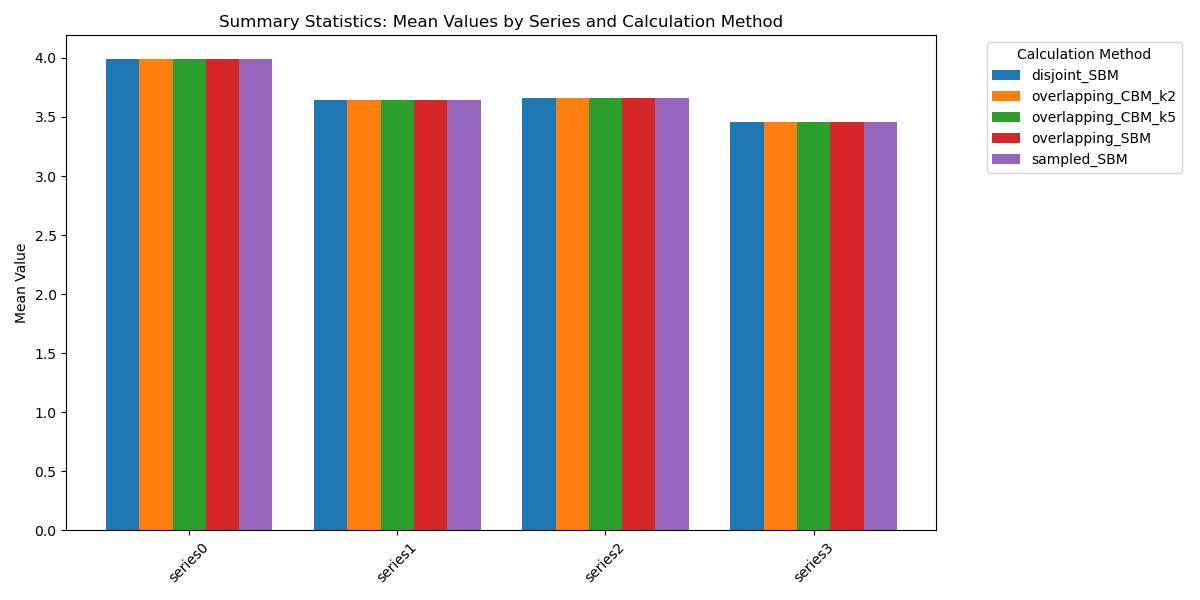

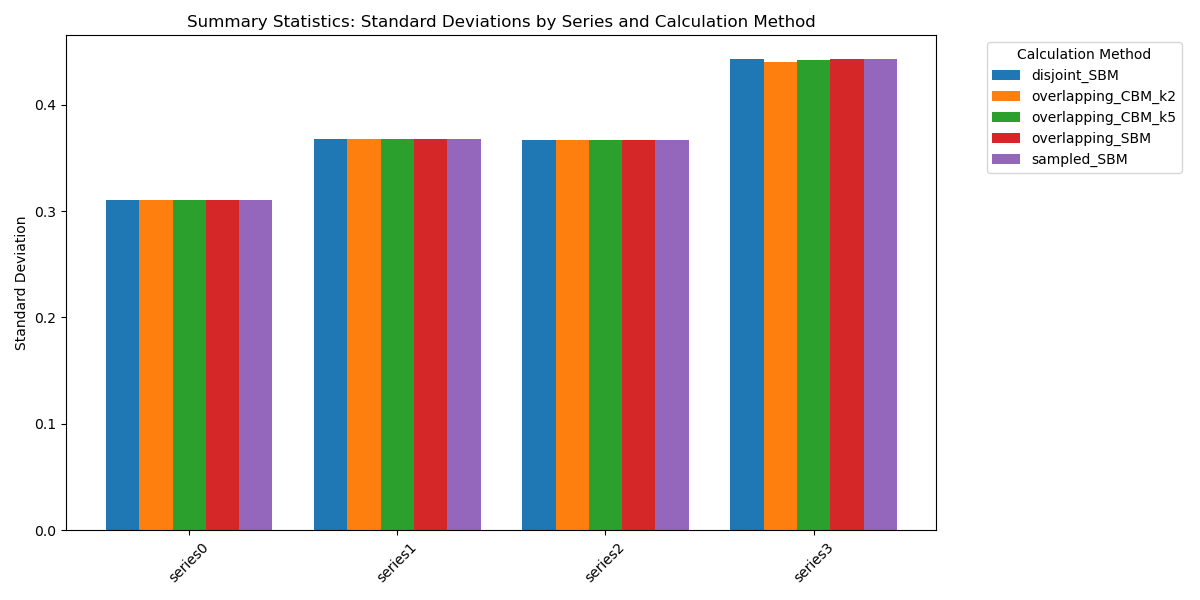

In [36]:
# Create a DataFrame to hold the summary statistics
summary_data = []

# Extract mean values from each calculation method for each series
for calc_method, series_dict in summary_stats.items():
    for series_name, stats in series_dict.items():
        # For overlapping, we have multiple columns (SBM, CBM_k2, CBM_k5)
        if calc_method == 'overlapping':
            for col in stats.columns:
                mean_value = stats[col]['mean']
                summary_data.append({
                    'Series': series_name,
                    'Calculation Method': f"{calc_method}_{col}",
                    'Mean Value': mean_value
                })
        else:
            # For disjoint and sampled, we just have SBM
            mean_value = stats['SBM']['mean']
            summary_data.append({
                'Series': series_name,
                'Calculation Method': f"{calc_method}_SBM",
                'Mean Value': mean_value
            })

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# Create pivot table for easier plotting
plot_df = summary_df.pivot(index='Series', columns='Calculation Method', values='Mean Value')

# Plot grouped bar chart for means
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_df.index))  # Series types
width = 0.8 / len(plot_df.columns)  # Width of each bar

for i, col in enumerate(plot_df.columns):
    offset = i * width - (len(plot_df.columns) - 1) * width / 2
    ax.bar(x + offset, plot_df[col], width, label=col)

# Add labels, title, and legend
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45)
ax.set_ylabel('Mean Value')
ax.set_title('Summary Statistics: Mean Values by Series and Calculation Method')
ax.legend(title='Calculation Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Create a DataFrame to hold the standard deviation statistics
std_summary_data = []

# Extract std values from each calculation method for each series
for calc_method, series_dict in summary_stats.items():
    for series_name, stats in series_dict.items():
        # For overlapping, we have multiple columns (SBM, CBM_k2, CBM_k5)
        if calc_method == 'overlapping':
            for col in stats.columns:
                std_value = stats[col]['std']
                std_summary_data.append({
                    'Series': series_name,
                    'Calculation Method': f"{calc_method}_{col}",
                    'Std Value': std_value
                })
        else:
            # For disjoint and sampled, we just have SBM
            std_value = stats['SBM']['std']
            std_summary_data.append({
                'Series': series_name,
                'Calculation Method': f"{calc_method}_SBM",
                'Std Value': std_value
            })

# Convert to DataFrame
std_summary_df = pd.DataFrame(std_summary_data)

# Create pivot table for easier plotting
std_plot_df = std_summary_df.pivot(index='Series', columns='Calculation Method', values='Std Value')

# Plot grouped bar chart for standard deviations
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(std_plot_df.index))  # Series types
width = 0.8 / len(std_plot_df.columns)  # Width of each bar

for i, col in enumerate(std_plot_df.columns):
    offset = i * width - (len(std_plot_df.columns) - 1) * width / 2
    ax.bar(x + offset, std_plot_df[col], width, label=col)

# Add labels, title, and legend
ax.set_xticks(x)
ax.set_xticklabels(std_plot_df.index, rotation=45)
ax.set_ylabel('Standard Deviation')
ax.set_title('Summary Statistics: Standard Deviations by Series and Calculation Method')
ax.legend(title='Calculation Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [37]:
for i, (name, means) in enumerate(estimators['means'].items()):
   for series_name in means.keys():
        estimators['means'][name][series_name] = means[series_name].rename(
            lambda x: x.replace('_mean', ''), axis=1)

for i, (name, stds) in enumerate(estimators['stds'].items()):
   for series_name in stds.keys():
        estimators['stds'][name][series_name] = stds[series_name].rename(
            lambda x: x.replace('_std', ''), axis=1)

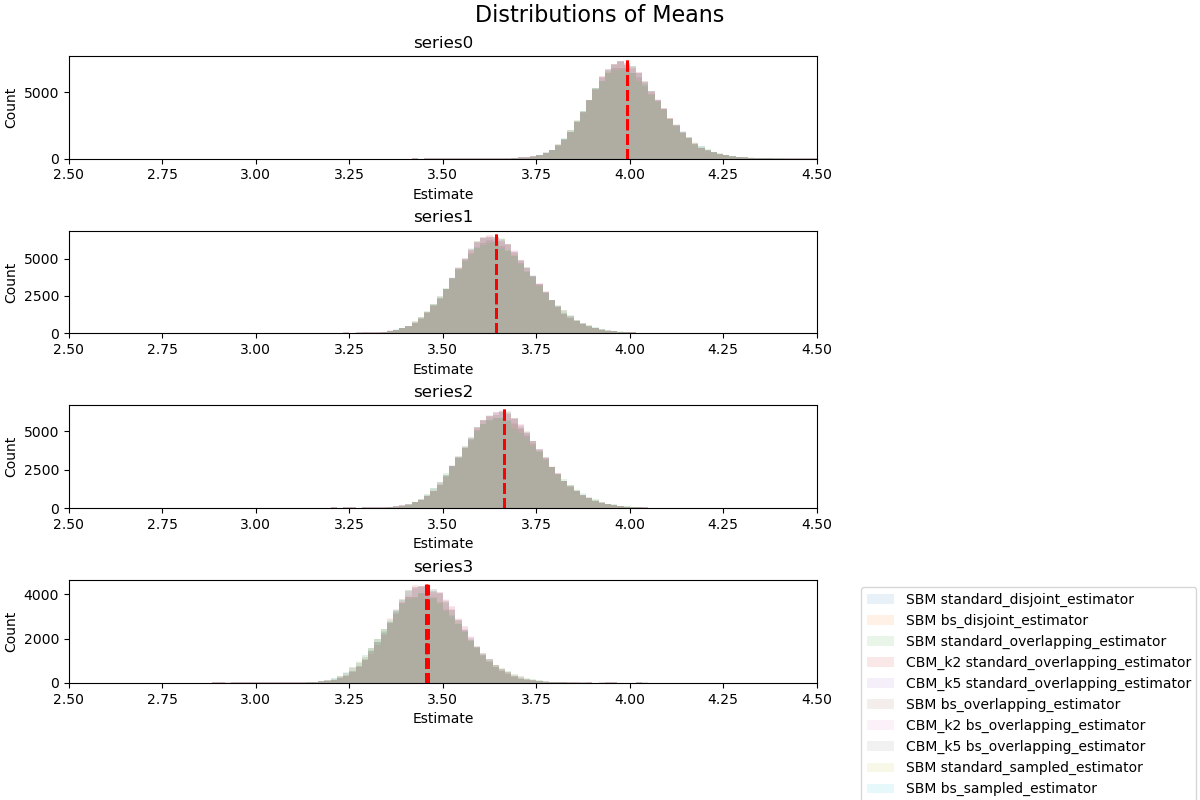

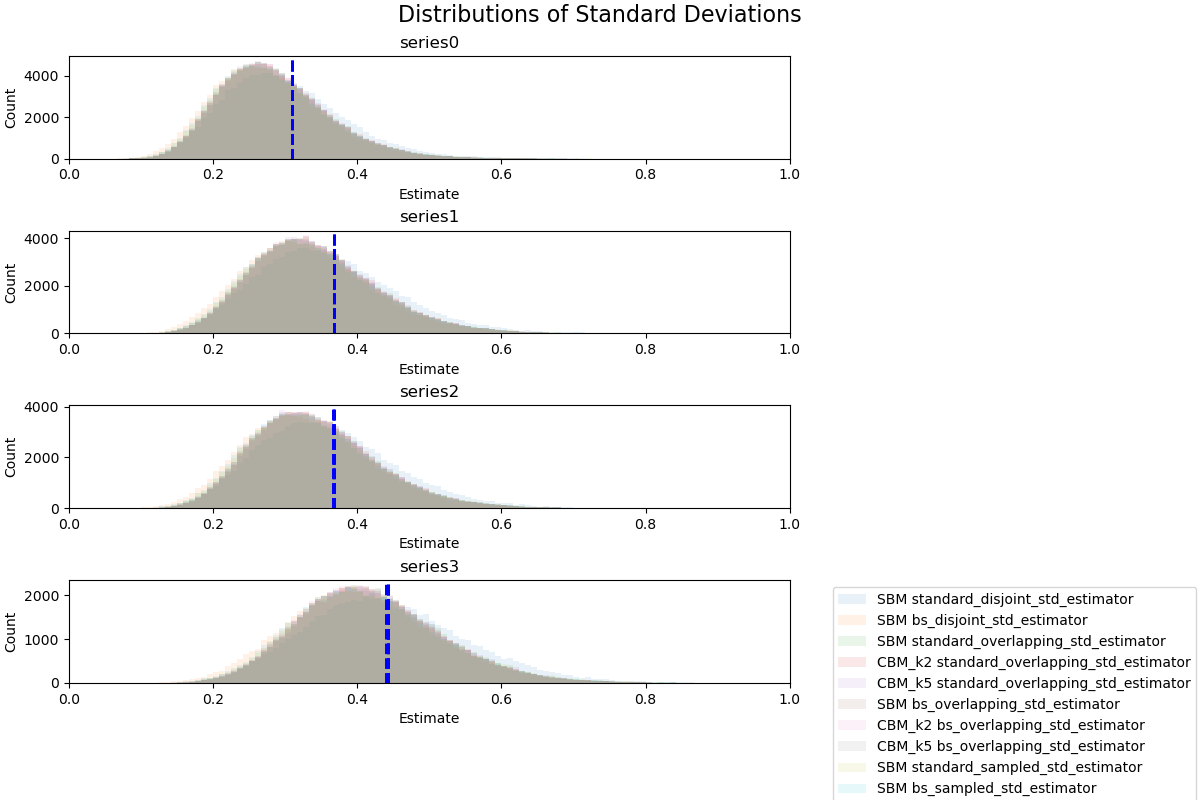

In [38]:
# Create figures for means and standard deviations
figures = {}
axes = {}

for metric, combined_data, x_limits, title in [
    ('means', estimators['means'], (2.5, 4.5), 'Distributions of Means'),
    ('stds', estimators['stds'], (0, 1), 'Distributions of Standard Deviations')
]:
    series_names = combined_data[list(combined_data.keys())[0]].keys()
    series_names = sorted(series_names)
    fig, axs = plt.subplots(len(series_names), 1, figsize=(12, 8), constrained_layout=True)
    figures[metric] = fig
    axes[metric] = axs

    for row_idx, name in enumerate(combined_data.keys()):
        data = combined_data[name]

        for col_idx, series_name in enumerate(series_names):
            ax = axs[col_idx]
            ax.set_xlim(*x_limits)  # Adjust x-axis limits for better visibility
            true_stat_str = name.split('_')[1]
            true_stats = summary_stats[true_stat_str][series_name]

            for col in data[series_name].columns:
                values = data[series_name][col].values
                true_value = true_stats[col]['mean'] if metric == 'means' else true_stats[col]['std']

                bins = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 121)  # 30 bins across x limits
                ax.hist(values, bins=bins, alpha=0.1, label=f'{col} {name}')
                ax.axvline(true_value, color='r' if metric == 'means' else 'b', linestyle='--', linewidth=2, label=None)
                # print(f"{series_name} {col} {name} std: {np.std(values)}")
                # q1, q3 = np.percentile(values, [25, 75])
                # print(f"{series_name} {col} {name} middle 50th percentile range: {q3 - q1}")
                # print()

            ax.set_title(f'{series_name}')
            ax.set_xlabel('Estimate')
            ax.set_ylabel('Count')

            if col_idx == len(series_names) - 1:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside to the right

    fig.suptitle(title, fontsize=16)
    plt.show()


In [39]:
# Assuming we already have:
# 1) estimators['means']: Dict of dataframes with mean estimates
# 2) estimators['stds']: Dict of dataframes with std estimates
# 3) summary_stats: Dict with true statistics from the dask compute

# --- Prepare result DataFrames ---
# First identify which estimator types we have
estimator_types = list(estimators['means'].keys())
# For each estimator type, identify which series are available
series_names = set()
for est_type in estimator_types:
    series_names.update(estimators['means'][est_type].keys())
series_names = sorted(list(series_names))  # Ensure consistent ordering

# Create a function to process a specific estimator type
def compute_metrics(est_type, combined_df, estimator):
    # Identify columns based on first available series/estimator
    first_series = next(iter(combined_df[est_type].keys()))
    cols = combined_df[est_type][first_series].columns
    
    bias = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    se = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    mse = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    iqr = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    
    # --- Fill with metrics ---
    for name in series_names:
        if name in combined_df[est_type]:
            for col in cols:
                est = combined_df[est_type][name][col].dropna().values
                true = summary_stats[est_type.split('_')[1]][name][col][estimator]
                # true = summary_stats[name]["SBM"]['mean']
                
                bias.at[name, col] = est.mean() - true
                se.at[name, col] = est.std(ddof=0)
                mse.at[name, col] = np.mean((est - true) ** 2)
                iqr.at[name, col] = np.percentile(est, 75) - np.percentile(est, 25)

                if np.isnan(bias.at[name, col]):
                    pass
                
    return {
        'bias': bias, 'se': se, 'mse': mse, 'iqr': iqr,
    }

# Compute metrics for each estimator type
results_means = {}
results_stds = {}
for est_type in estimator_types:
    std_est_type = est_type.replace('_estimator', '_std_estimator')
    results_means[est_type] = compute_metrics(est_type, estimators['means'], "mean")
    results_stds[est_type] = compute_metrics(std_est_type, estimators['stds'], "std")
    
    print(f"\n=== Metrics for {est_type} ===")
    print("Bias of mean estimates:\n",  results_means[est_type]['bias'])
    print("\nSE of mean estimates:\n",  results_means[est_type]['se'])
    print("\nMSE of mean estimates:\n", results_means[est_type]['mse'])
    print("\nIQR of mean estimates:\n", results_means[est_type]['iqr'])
    
    print("\nBias of std estimates:\n", results_stds[est_type]['bias'])
    print("\nSE of std estimates:\n",   results_stds[est_type]['se'])
    print("\nMSE of std estimates:\n",  results_stds[est_type]['mse'])
    print("\nIQR of std estimates:\n",  results_stds[est_type]['iqr'])



=== Metrics for standard_disjoint_estimator ===
Bias of mean estimates:
                   SBM
series0  8.881784e-16
series1  0.000000e+00
series2 -4.440892e-16
series3  8.881784e-16

SE of mean estimates:
               SBM
series0  0.097648
series1  0.109407
series2  0.107918
series3  0.104973

MSE of mean estimates:
               SBM
series0  0.009535
series1  0.011970
series2  0.011646
series3  0.011019

IQR of mean estimates:
               SBM
series0  0.130845
series1  0.146587
series2  0.144649
series3  0.140946

Bias of std estimates:
               SBM
series0 -0.011785
series1 -0.010771
series2 -0.010081
series3 -0.003427

SE of std estimates:
               SBM
series0  0.085150
series1  0.097667
series2  0.096677
series3  0.112221

MSE of std estimates:
               SBM
series0  0.007389
series1  0.009655
series2  0.009448
series3  0.012605

IQR of std estimates:
               SBM
series0  0.110834
series1  0.128731
series2  0.127822
series3  0.147842

=== Metrics for

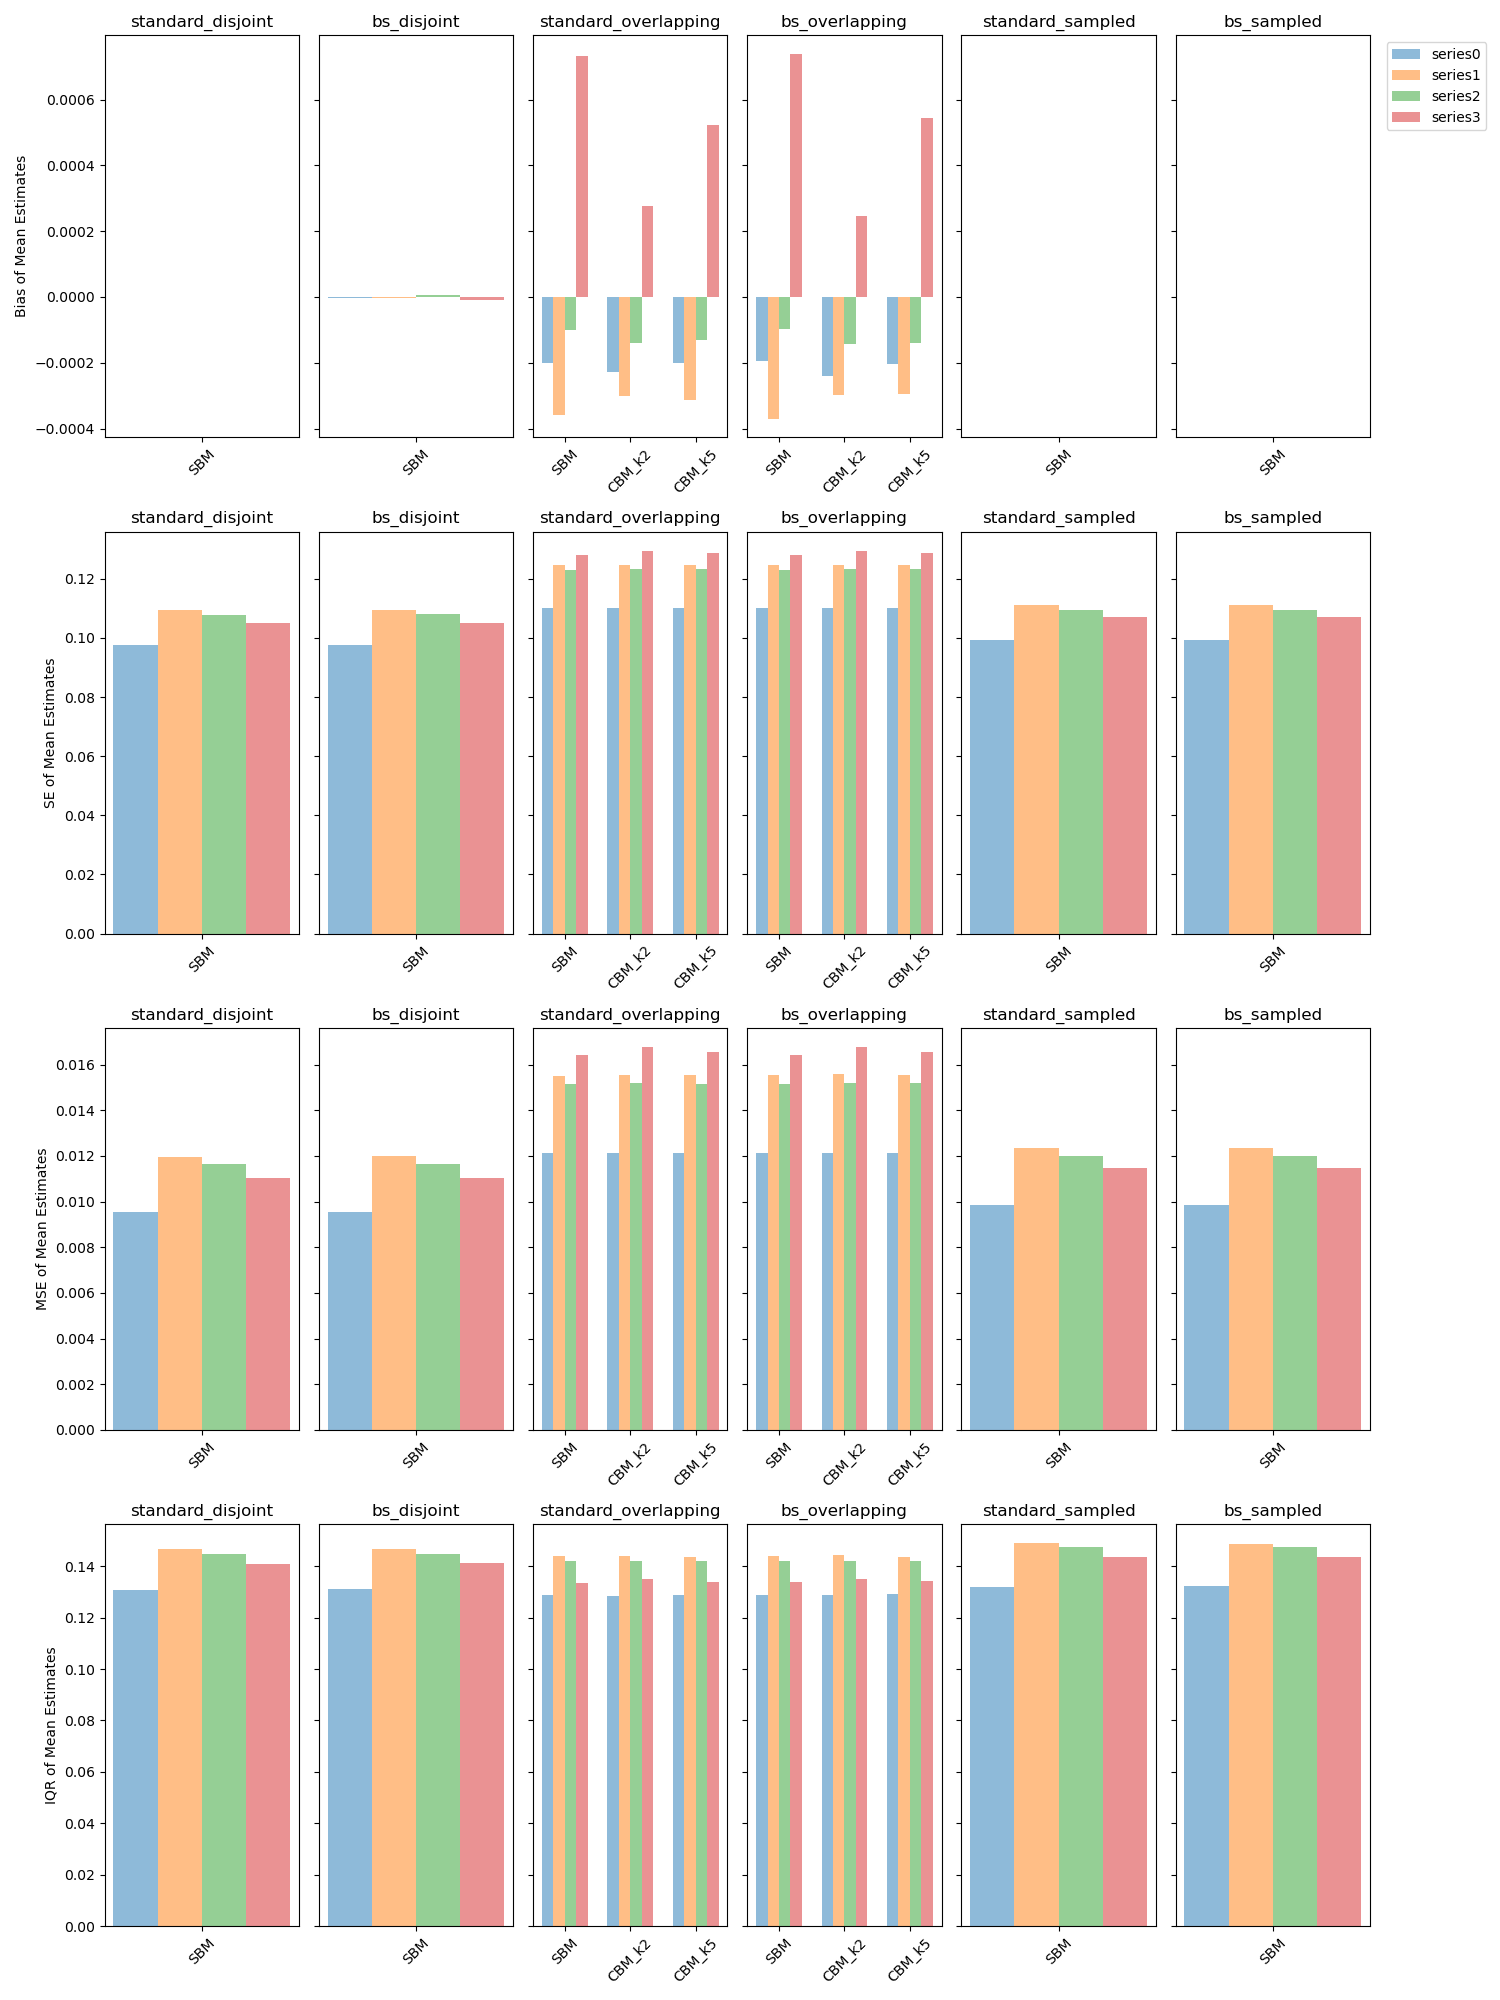

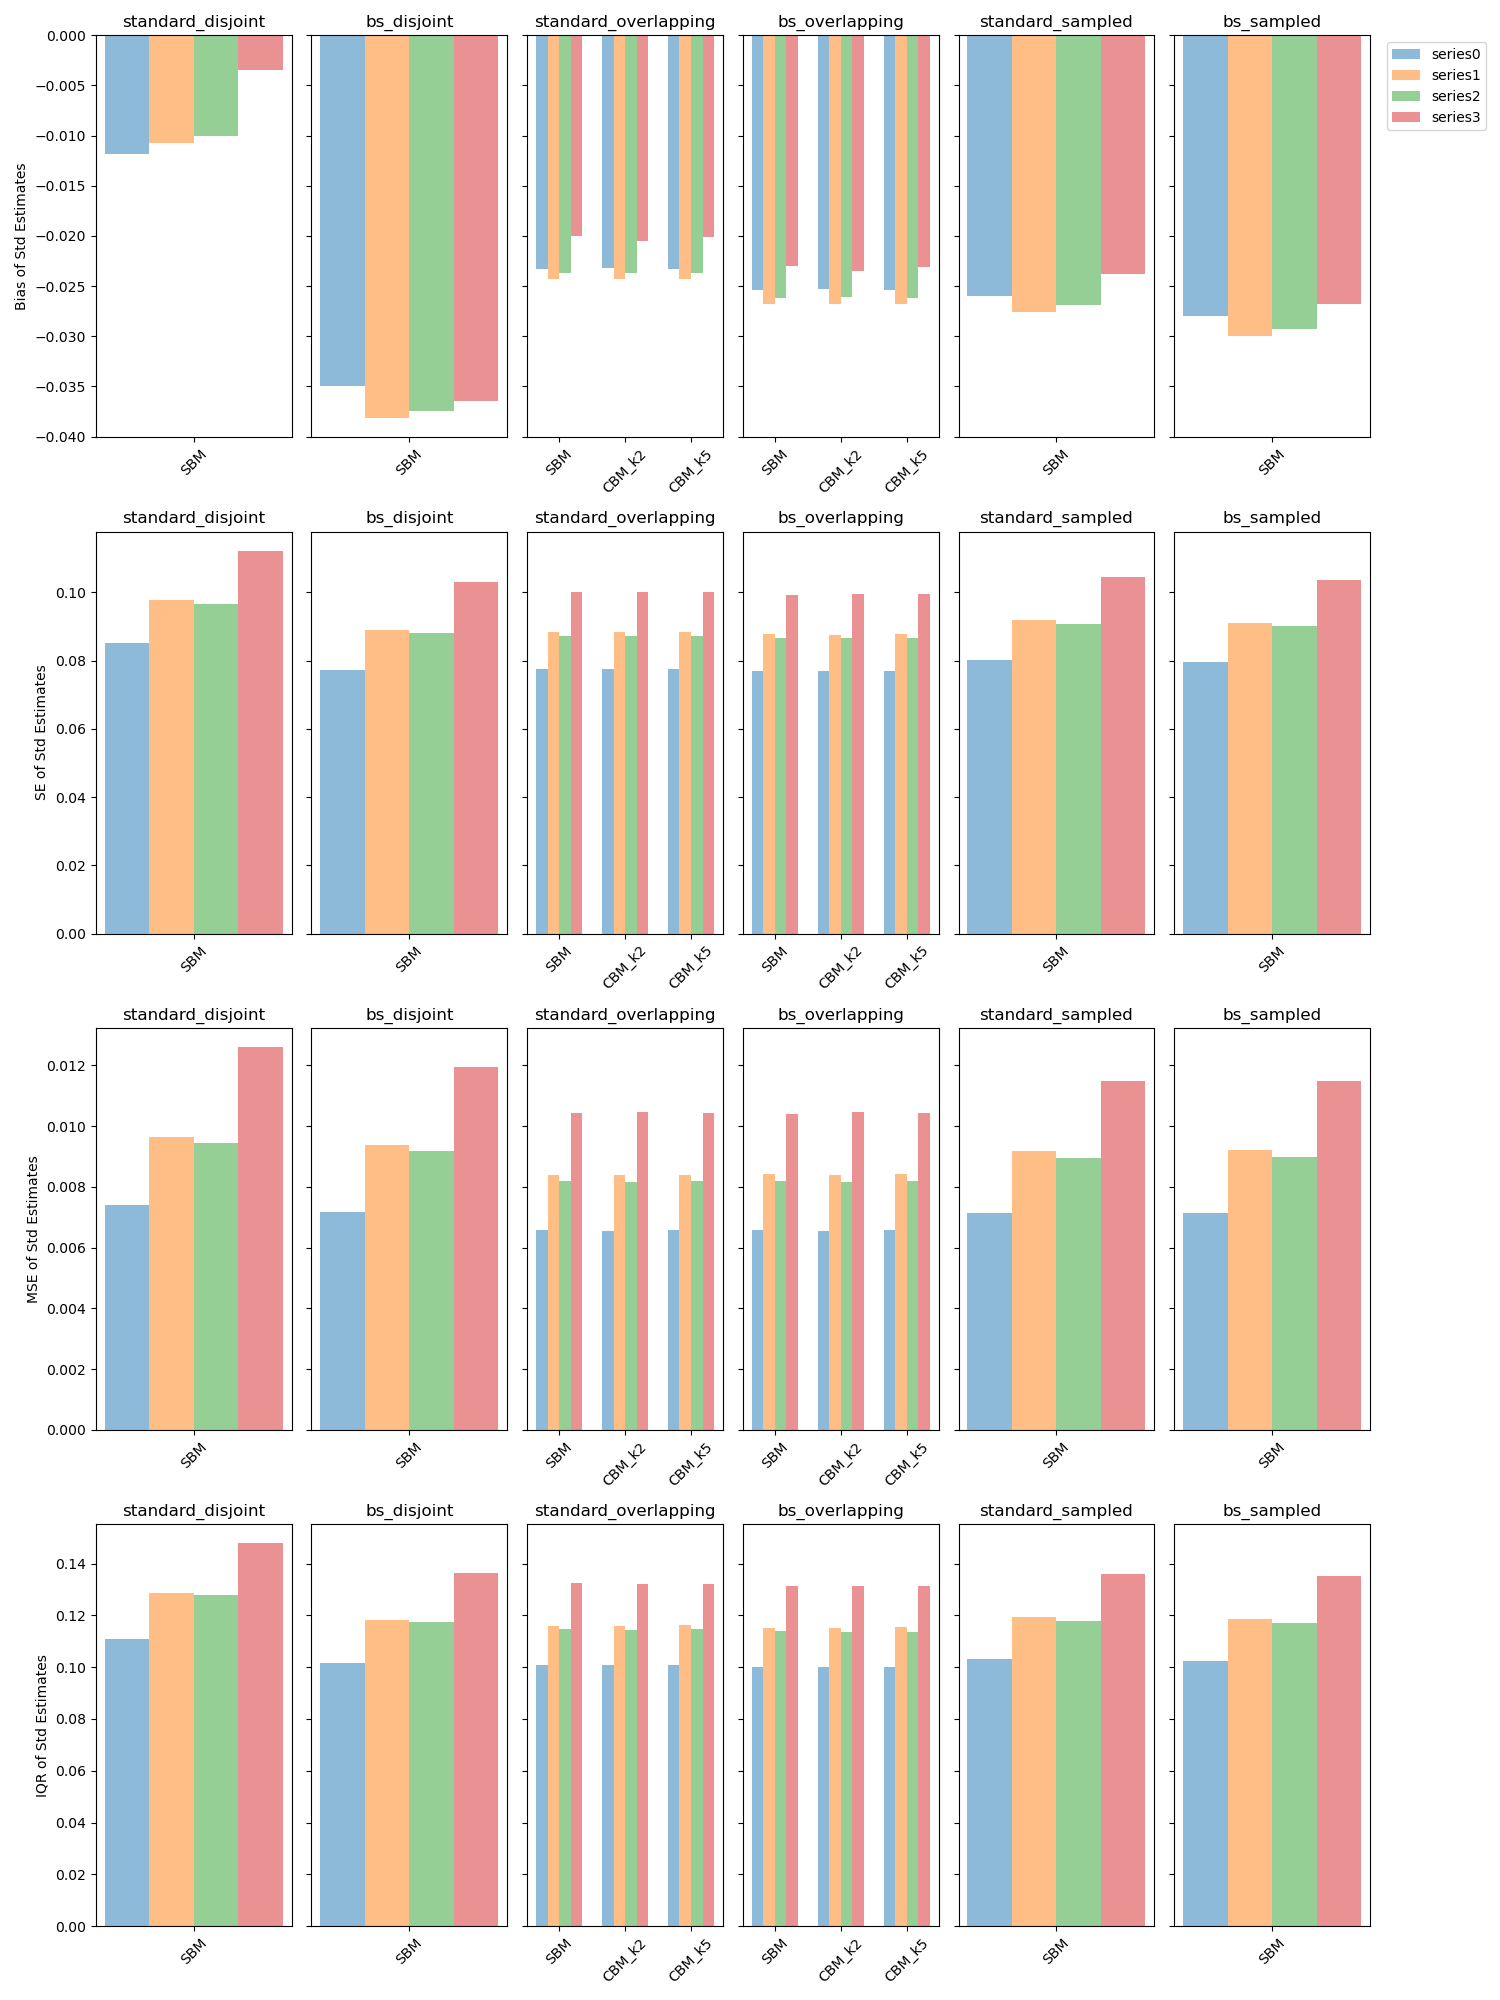

In [40]:
titles = ["Bias of Mean Estimates", "SE of Mean Estimates", "MSE of Mean Estimates", "IQR of Mean Estimates", "Bias of Std Estimates", "SE of Std Estimates", "MSE of Std Estimates", "IQR of Std Estimates"]
metrics = ['bias', 'se', 'mse', 'iqr']

# Transpose the DataFrame to swap columns and rows
for fig_idx, (results, metric_titles) in enumerate(zip([results_means, results_stds], 
                                                       [titles[:len(metrics)], titles[len(metrics):]])):
    fig, axs = plt.subplots(len(metrics), len(estimator_types), figsize=(15, 5 * len(metrics)), layout='tight', sharey='row')  # Share y-axis across rows

    for col_idx, est_type in enumerate(estimator_types):  # Iterate over columns (estimator types)
        for row_idx, (metric, title) in enumerate(zip(metrics, metric_titles)):  # Iterate over rows (metrics)
            ax = axs[row_idx, col_idx] if len(estimator_types) > 1 else axs[row_idx]
            
            # Get the metric dataframe for this estimator and transpose it
            df = results[est_type][metric].T
            
            # For each series, plot a grouped bar chart
            x = np.arange(len(df.index))
            width = 0.7 / len(df.columns)  # Width of each bar
            
            for j, col in enumerate(df.columns):
                offset = width * j - (len(df.columns) - 1) * width / 2
                ax.bar(x + offset, df[col], width, alpha=0.5, 
                       label=f'{col}')
            
            ax.set_title(est_type.replace('_estimator', ''))
            ax.set_xticks(x)
            ax.set_xticklabels(df.index, rotation=45)  # Use transposed index as labels
            
            if row_idx == 0 and col_idx == len(estimator_types)-1:  # Only show legend on the first plot
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

            if col_idx == 0:  # Only set y-labels for the first column
                ax.set_ylabel(title)

    plt.tight_layout()
    plt.suptitle(f'Figure {fig_idx + 1}: {metric_titles[0].split()[2]} Metrics', fontsize=16, y=1.02)
    plt.show()
